In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.size'] = 12

# player list 불러오기
players = pd.read_csv('../data/player_list.csv')
print(players)

  name_korean    name_english          tier position  mlb_debut_year  \
0         박찬호    Chan Ho Park  1A_Sustained        P          1994.0   
1         김병현  Byung-Hyun Kim       1B_Peak        P          1999.0   
2         추신수   Shin-Soo Choo  1A_Sustained       OF          2005.0   
3         배지환     Ji Hwan Bae         2_Mid    OF/IF          2022.0   
4         최지만     Ji-Man Choi         2_Mid       1B          2016.0   
5         봉중근       Jung Bong         2_Mid        P          2002.0   
6         조원빈     Won-Bin Cho    3_Prospect       OF             NaN   
7         김성준   Seong-Jun Kim    3_Prospect   SS/RHP             NaN   
8         문서준     Seojun Moon      4_Newest        P             NaN   

   signing_year signing_team  key_mlbam  
0          1994          LAD   120221.0  
1          1997          ARI   218294.0  
2          2001          SEA   425783.0  
3          2018          PIT   678225.0  
4          2010          SEA   596847.0  
5          1997          AT

차트 저장 완료: visualizations/01_signing_timeline.png


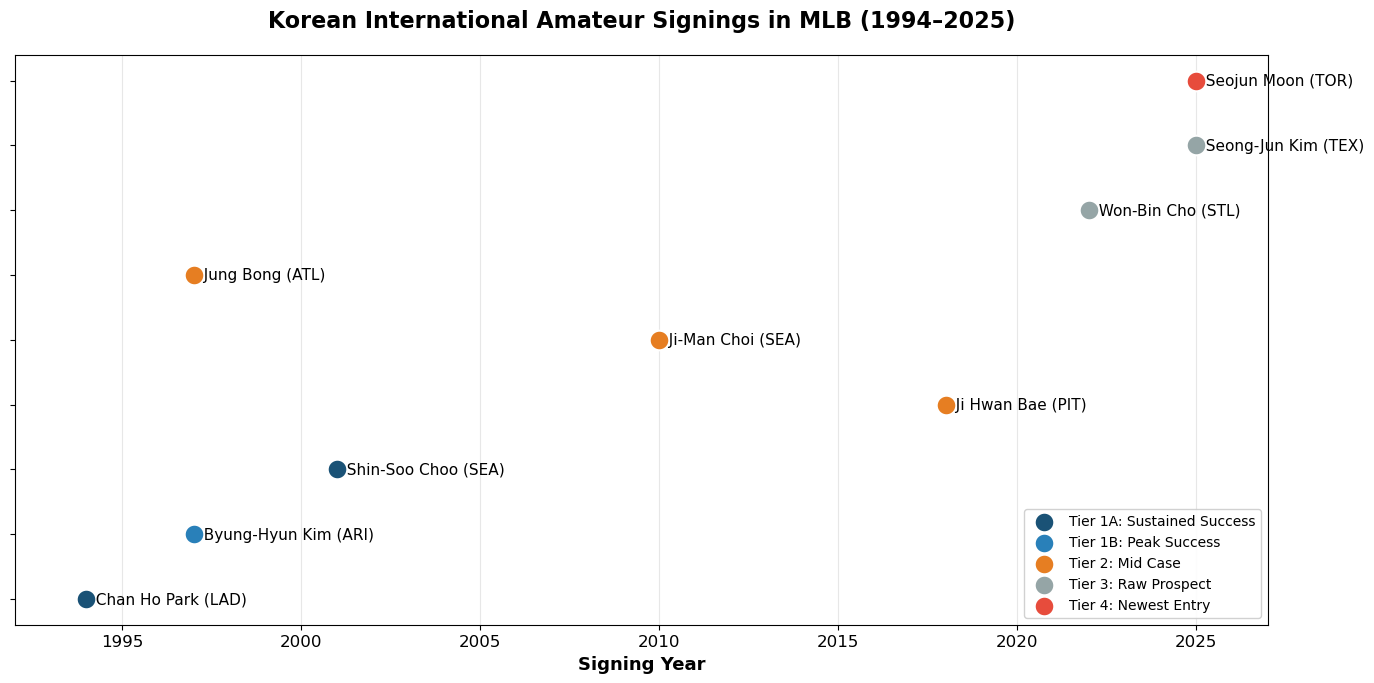

In [2]:
# 색상 설정 (Tier별)
tier_colors = {
    '1A_Sustained': '#1a5276',   # 진한 파란색
    '1B_Peak': '#2980b9',        # 밝은 파란색
    '2_Mid': '#e67e22',          # 주황색
    '3_Prospect': '#95a5a6',     # 회색
    '4_Newest': '#e74c3c'        # 빨간색 (Blue Jays 강조)
}

tier_labels = {
    '1A_Sustained': 'Tier 1A: Sustained Success',
    '1B_Peak': 'Tier 1B: Peak Success',
    '2_Mid': 'Tier 2: Mid Case',
    '3_Prospect': 'Tier 3: Raw Prospect',
    '4_Newest': 'Tier 4: Newest Entry'
}

fig, ax = plt.subplots(figsize=(14, 7))

# 각 선수를 점으로 표시
for i, row in players.iterrows():
    color = tier_colors[row['tier']]
    label = tier_labels[row['tier']]
    
    # 같은 tier는 범례 중복 방지
    if label in [t.get_label() for t in ax.collections]:
        label = '_nolegend_'
    
    ax.scatter(row['signing_year'], i, 
               c=color, s=200, zorder=3, label=label,
               edgecolors='white', linewidth=1.5)
    
    # 선수 이름 표시
    ax.annotate(f"  {row['name_english']} ({row['signing_team']})", 
                xy=(row['signing_year'], i),
                fontsize=11, va='center')

# 축 설정
ax.set_yticks(range(len(players)))
ax.set_yticklabels([''] * len(players))  # y축 라벨 숨기기 (이름은 annotate로 표시)
ax.set_xlabel('Signing Year', fontsize=13, fontweight='bold')
ax.set_title('Korean International Amateur Signings in MLB (1994–2025)', 
             fontsize=16, fontweight='bold', pad=20)

# 그리드
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(1992, 2027)

# 범례
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)

# 레이아웃
plt.tight_layout()

# 저장
plt.savefig('../visualizations/01_signing_timeline.png', dpi=150, bbox_inches='tight')
print("차트 저장 완료: visualizations/01_signing_timeline.png")
plt.show()

차트 저장 완료: visualizations/02_career_length_by_tier.png


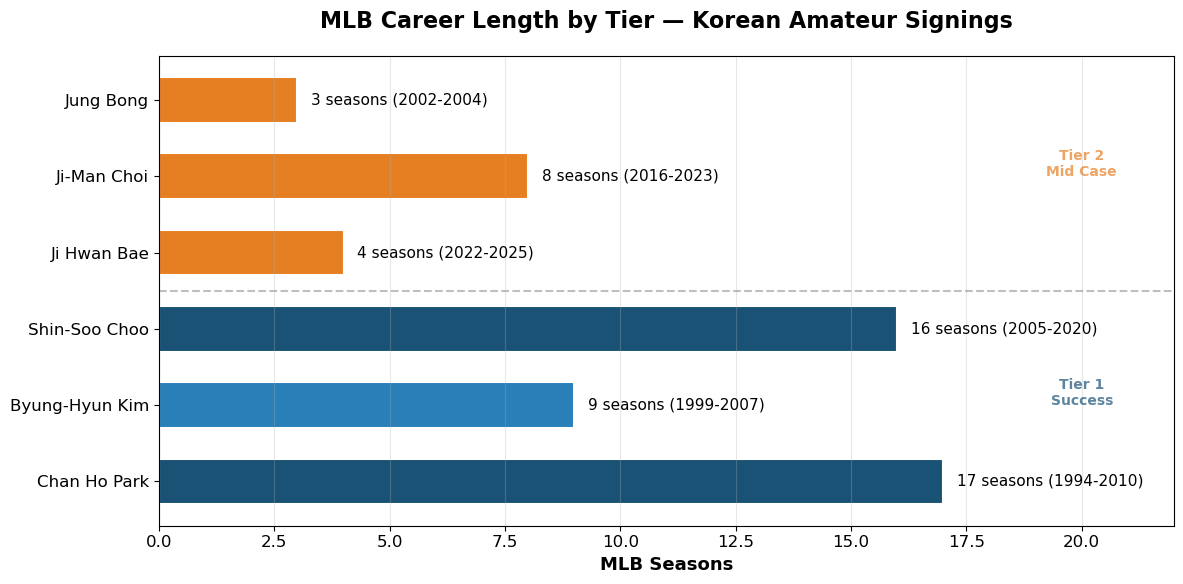

In [3]:
# MLB 활동 기간 데이터 (수동 정리 — Statcast 이전 선수 포함)
career_data = pd.DataFrame({
    'name': ['Chan Ho Park', 'Byung-Hyun Kim', 'Shin-Soo Choo',
             'Ji Hwan Bae', 'Ji-Man Choi', 'Jung Bong'],
    'tier': ['1A_Sustained', '1B_Peak', '1A_Sustained',
             '2_Mid', '2_Mid', '2_Mid'],
    'mlb_start': [1994, 1999, 2005, 2022, 2016, 2002],
    'mlb_end': [2010, 2007, 2020, 2025, 2023, 2004],
    'signing_age': [21, 20, 18, 18, 17, 22]
})

career_data['mlb_years'] = career_data['mlb_end'] - career_data['mlb_start'] + 1

fig, ax = plt.subplots(figsize=(12, 6))

# 수평 막대 그래프
bars = ax.barh(range(len(career_data)), career_data['mlb_years'],
               color=[tier_colors[t] for t in career_data['tier']],
               edgecolor='white', linewidth=1.5, height=0.6)

# 선수 이름 + 기간 표시
for i, row in career_data.iterrows():
    ax.text(row['mlb_years'] + 0.3, i, 
            f"{row['mlb_years']} seasons ({row['mlb_start']}-{row['mlb_end']})",
            va='center', fontsize=11)

ax.set_yticks(range(len(career_data)))
ax.set_yticklabels(career_data['name'], fontsize=12)
ax.set_xlabel('MLB Seasons', fontsize=13, fontweight='bold')
ax.set_title('MLB Career Length by Tier — Korean Amateur Signings', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlim(0, 22)
ax.grid(axis='x', alpha=0.3)

# Tier 구분선 추가
ax.axhline(y=2.5, color='gray', linestyle='--', alpha=0.5)
ax.text(20, 1, 'Tier 1\nSuccess', fontsize=10, ha='center', 
        color='#1a5276', fontweight='bold', alpha=0.7)
ax.text(20, 4, 'Tier 2\nMid Case', fontsize=10, ha='center', 
        color='#e67e22', fontweight='bold', alpha=0.7)

plt.tight_layout()
plt.savefig('../visualizations/02_career_length_by_tier.png', dpi=150, bbox_inches='tight')
print("차트 저장 완료: visualizations/02_career_length_by_tier.png")
plt.show()

## Key Observations

### Chart 1: Signing Timeline
- Korean amateur signings span 30 years (1994-2025)
- Three distinct waves: 1990s pioneers, 2000s-2010s second wave, 2020s current wave
- Toronto Blue Jays entered the Korean amateur market last (2025) with Seojun Moon

### Chart 2: Career Length
- Tier 1 success cases averaged 13+ MLB seasons
- Tier 2 mid cases averaged 3-7 seasons
- Clear correlation between tier and career longevity